# Placement Package Prediction

Predict placement package (LPA) from a student's SPI and IQ.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



In [10]:
df = pd.read_csv('placement-data.csv')
df.head(1)


,SPI,IQ,Package(LPA)
0,7.5,156,8.62


In [13]:
print('Shape:', df.shape)

display(df.info())

display(df.describe())

print('Missing values:')
display(df.isnull().sum())

Shape: (500, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SPI           500 non-null    float64
 1   IQ            500 non-null    int64  
 2   Package(LPA)  500 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


None

,SPI,IQ,Package(LPA)
count,500.000000,500.000000,500.000000
mean,7.898900,119.456000,7.304620
std,1.186938,22.796742,2.636771
min,6.020000,80.000000,1.030000
25%,6.857500,99.750000,5.437500
50%,7.845000,119.000000,7.340000
75%,8.860000,139.000000,9.170000
max,10.000000,159.000000,13.330000


Missing values:


SPI             0
IQ              0
Package(LPA)    0
dtype: int64

In [14]:
# Remove duplicate rows and rows with missing values.
df_cleaned = df.drop_duplicates().dropna().copy()
print('Shape after cleaning:', df_cleaned.shape)

Shape after cleaning: (500, 3)


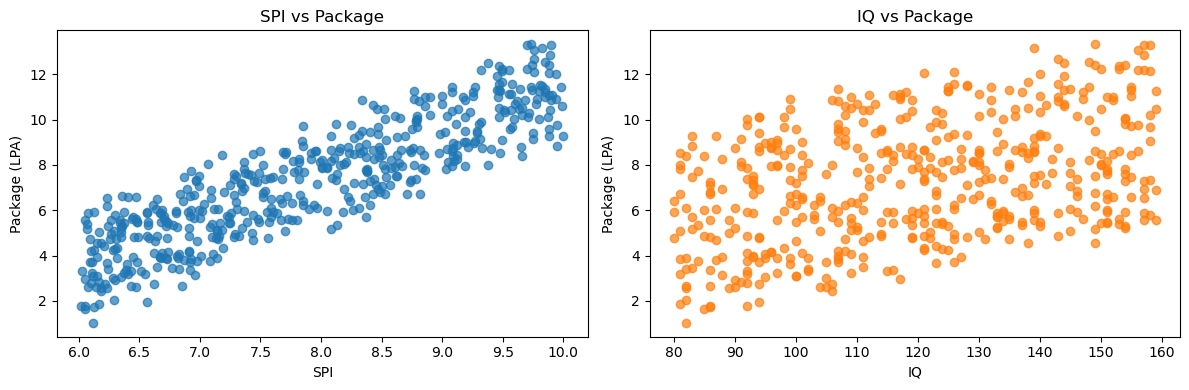

In [18]:
# Visualize the relationships with the target.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df_cleaned['SPI'], df_cleaned['Package(LPA)'], alpha=0.7)
axes[0].set(xlabel='SPI', ylabel='Package (LPA)', title='SPI vs Package')
axes[1].scatter(df_cleaned['IQ'], df_cleaned['Package(LPA)'], alpha=0.7, color='tab:orange')
axes[1].set(xlabel='IQ', ylabel='Package (LPA)', title='IQ vs Package')
plt.tight_layout()
plt.show()

Rows used for modeling: 500 of 500


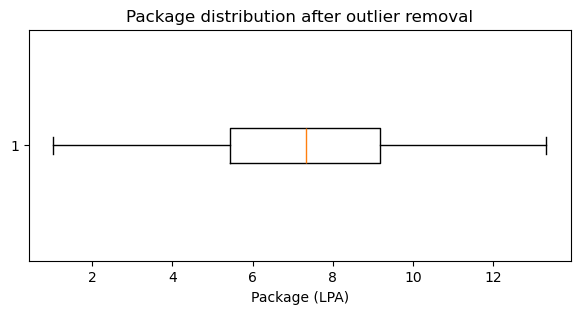

In [25]:
# Remove extreme package values using the IQR rule.
target = 'Package(LPA)'

q1, q3 = df_cleaned[target].quantile([0.25, 0.75])

iqr = q3 - q1

lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr

df_model = df_cleaned[df_cleaned[target].between(lower_bound, upper_bound)].copy()

print(f'Rows used for modeling: {len(df_model)} of {len(df_cleaned)}')

plt.figure(figsize=(7, 3))
plt.boxplot(df_model[target], vert=False)
plt.xlabel('Package (LPA)')
plt.title('Package distribution after outlier removal')
plt.show()

In [30]:
# Save the cleaned dataset for reuse.
df_model.to_csv('placement_data_cleaned.csv', index=False)

In [31]:
feature_columns = ['SPI', 'IQ']
X = df_model[feature_columns]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print('Training R²:', round(model.score(X_train_scaled, y_train), 4))
print('Testing R²:', round(model.score(X_test_scaled, y_test), 4))
print('MSE:', round(mean_squared_error(y_test, y_pred), 4))
print('R² score:', round(r2_score(y_test, y_pred), 4))
print('Coefficients (SPI, IQ):', model.coef_)
print('Intercept:', model.intercept_)

Training R²: 0.9679
Testing R²: 0.9571
MSE: 0.2653
R² score: 0.9571
Coefficients (SPI, IQ): [2.35111591 1.1424061 ]
Intercept: 7.244299999999997


In [48]:
# Linear regression trained manually with gradient descent.
X_train_gd = X_train_scaled.astype(float)
X_test_gd = X_test_scaled.astype(float)
y_train_gd = y_train.to_numpy(dtype=float)
y_test_gd = y_test.to_numpy(dtype=float)

#prediction = (feature × weight) + bias

weights = np.zeros(X_train_gd.shape[1])
bias = 0.0
learning_rate = 0.01
epochs = 2000
loss_history = []

for _ in range(epochs):
    predictions = X_train_gd @ weights + bias
    error = predictions - y_train_gd
    loss_history.append(np.mean(error ** 2))
    weights =weights- learning_rate * (2 / len(X_train_gd)) * (X_train_gd.T @ error)
    bias -= learning_rate * 2 * error.mean()

gd_predictions = X_test_gd @ weights + bias
print('Gradient-descent MSE:', round(mean_squared_error(y_test_gd, gd_predictions), 4))
print('Gradient-descent R²:', round(r2_score(y_test_gd, gd_predictions), 4))

Gradient-descent MSE: 0.2653
Gradient-descent R²: 0.9571


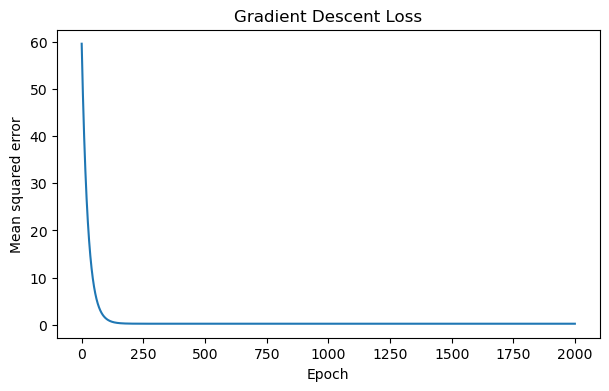

In [49]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Mean squared error')
plt.title('Gradient Descent Loss')
plt.show()

In [51]:
# Predict the expected package for a new student.
new_student = pd.DataFrame({'SPI': [9.00], 'IQ': [150]})
predicted_package = model.predict(scaler.transform(new_student))[0]
print(f'Predicted package: {predicted_package:.2f} LPA')

Predicted package: 10.99 LPA
